## Lecture 4

In this notebook we implement the full GAN training methodology: the Generator, the Maxout activation, the Discriminator, and the training loop, then visualize generated MNIST digits.

In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
device = torch.device('cpu')
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')

device

device(type='mps')

In [3]:
noise_dim = 100

Generator Model

In [4]:
class Generator(torch.nn.Module):

    def __init__(self):

        super(Generator, self).__init__()

        self.fcn = torch.nn.Sequential(
            # Fully Connected Layer 1
            torch.nn.Linear(
                in_features=noise_dim,
                out_features=1200,
                bias=True
            ),
            torch.nn.ReLU(),
            torch.nn.Dropout(),
            # Fully Connected Layer 2
            torch.nn.Linear(
                in_features=1200,
                out_features=1200,
                bias=True
            ),
            torch.nn.ReLU(),
            torch.nn.Dropout(),
            # Fully Connected Layer 3
            torch.nn.Linear(
                in_features=1200,
                out_features=1200,
                bias=True
            ),
            torch.nn.ReLU(),
            torch.nn.Dropout(),
            # Fully Connected Layer 4
            torch.nn.Linear(
                in_features=1200,
                out_features=784,
                bias=True
            ),
            torch.nn.Sigmoid()
        )

    def forward(self, batch):
        ret = batch.view(batch.size(0), -1)
        ret = self.fcn(ret)
        return ret

Maxout Activation

Source: [https://github.com/pytorch/pytorch/issues/805](https://github.com/pytorch/pytorch/issues/805)

In [5]:
class Maxout(torch.nn.Module):

    def __init__(self, num_pieces):

        super(Maxout, self).__init__()

        self.num_pieces = num_pieces

    def forward(self, x):

        # x.shape = (batch_size? x 625)

        assert x.shape[1] % self.num_pieces == 0  # 625 % 5 = 0

        ret = x.view(
            *x.shape[:1],  # batch_size
            x.shape[1] // self.num_pieces,  # piece-wise linear
            self.num_pieces,  # num_pieces
            *x.shape[2:]  # remaining dimensions if any
        )

        # ret.shape = (batch_size? x 125 x 5)

        # https://pytorch.org/docs/stable/torch.html#torch.max
        ret, _ = ret.max(dim=2)

        # ret.shape = (batch_size? x 125)

        return ret

Discriminator Model

In [6]:
class Discriminator(torch.nn.Module):

    def __init__(self):

        super(Discriminator, self).__init__()

        self.fcn = torch.nn.Sequential(
            # Fully Connected Layer 1
            torch.nn.Linear(
                in_features=784,
                out_features=625,
                bias=True
            ),
            Maxout(5),
            # Fully Connected Layer 2
            torch.nn.Linear(
                in_features=125,
                out_features=625,
                bias=True
            ),
            Maxout(5),
            # Fully Connected Layer 3
            torch.nn.Linear(
                in_features=125,
                out_features=1,
                bias=True
            ),
            torch.nn.Sigmoid()
        )

    def forward(self, batch):
        ret = batch.view(batch.size(0), -1)
        ret = self.fcn(ret)
        return ret

## Lecture 4

MNIST Dataset

In [7]:
import torchvision

In [8]:
class FlattenTransform:

    def __call__(self, inputs):
        return inputs.view(inputs.shape[0], -1)


data_train = torchvision.datasets.MNIST(
    './data/mnist',
    train=True,
    download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        FlattenTransform()
    ])
)

In [9]:
BATCH_SIZE = 32

train_loader = torch.utils.data.DataLoader(
    data_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

GAN Training

In [10]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)


discriminator_optimizer = torch.optim.SGD(
    discriminator.parameters(),
    lr=0.0002,
    momentum=0.5
)

generator_optimizer = torch.optim.SGD(
    generator.parameters(),
    lr=0.0002,
    momentum=0.5
)

criterion = torch.nn.BCELoss()

In [11]:
real_labels = torch.ones(BATCH_SIZE, 1).to(device)
fake_labels = torch.zeros(BATCH_SIZE, 1).to(device)

test_set = torch.randn(16, noise_dim).to(device)

num_epochs = 512
num_steps = len(train_loader) // BATCH_SIZE

In [12]:
import os

if not os.path.exists('visuals'):
    os.mkdir('visuals')

In [13]:
for epoch in range(num_epochs):

    for i, (images, _) in enumerate(train_loader):

        if i == num_steps:
            break

        # Train Discriminator
        for _ in range(1):

            real_images = images.to(device)

            fake_images = generator(
                torch.randn(BATCH_SIZE, noise_dim).to(device)
            )

            discriminator_optimizer.zero_grad()

            real_outputs = discriminator(real_images)
            fake_outputs = discriminator(fake_images)

            d_x = criterion(real_outputs, real_labels)
            d_g_z = criterion(fake_outputs, fake_labels)

            d_x.backward()
            d_g_z.backward()

            discriminator_optimizer.step()

        # Train Generator
        z = torch.randn(BATCH_SIZE, noise_dim).to(device)

        generator.zero_grad()

        outputs = discriminator(generator(z))

        loss = criterion(outputs, real_labels)

        loss.backward()

        generator_optimizer.step()

    # Visualize Results
    if epoch % 10 == 0:

        generated = generator(test_set).detach().cpu().view(-1, 1, 28, 28)

        grid = torchvision.utils.save_image(
            generated,
            os.path.join(
                'visuals',
                '{}.jpg'.format(
                    str(epoch).zfill(6)
                )
            ),
            nrow=4,
            padding=10,
            pad_value=1
        )

Visualize the final generated results after training.

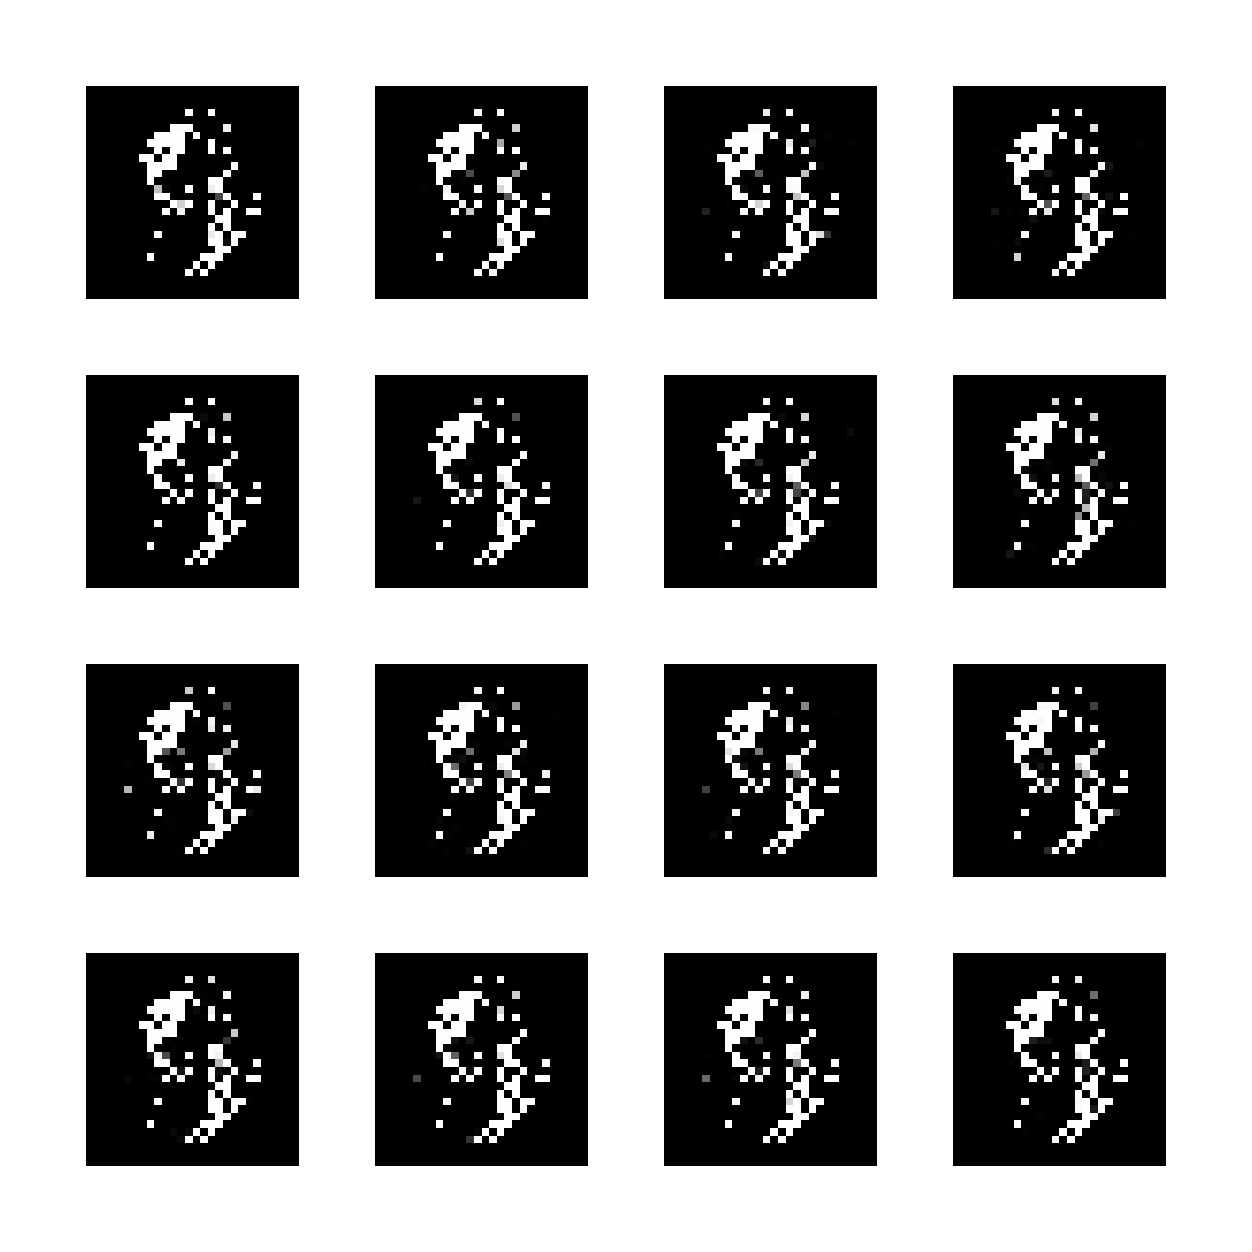

In [14]:
# Visualize Results
generated = generator(test_set).detach().cpu().view(-1, 1, 28, 28)

grid = torchvision.utils.make_grid(
    generated,
    nrow=4,
    padding=10,
    pad_value=1
)

img = np.transpose(
    grid.numpy(),
    (1, 2, 0)
)

fig = plt.figure(figsize=(16, 16))
plt.axis("off")
plt.imshow(img);

Google Collaboratory

Notebook: [https://colab.research.google.com/drive/14zSDErgZ8cNn9UEHgh2x2tPhao9HVYn5](https://colab.research.google.com/drive/14zSDErgZ8cNn9UEHgh2x2tPhao9HVYn5)

### Alternate run with a higher learning rate (Version 2)

In the course video, the instructor re-runs training with an updated learning rate and momentum (`lr=0.005`, `momentum=0.7`), and trains the discriminator for 16 steps per generator step (instead of 1). The cell below reproduces this alternate configuration -- run it (instead of the training cell above) if you want to see this variant. With `lr=0.005` and 16 discriminator steps per generator step, the outputs after training start to resemble MNIST digits (in the video, mostly 5s and other loosely-formed digits) rather than pure noise.

In [15]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

discriminator_optimizer = torch.optim.SGD(
    discriminator.parameters(),
    lr=0.005,
    momentum=0.7
)

generator_optimizer = torch.optim.SGD(
    generator.parameters(),
    lr=0.005,
    momentum=0.7
)

criterion = torch.nn.BCELoss()

real_labels = torch.ones(BATCH_SIZE, 1).to(device)
fake_labels = torch.zeros(BATCH_SIZE, 1).to(device)

test_set = torch.randn(16, noise_dim).to(device)

num_epochs = 512
num_steps = len(train_loader) // BATCH_SIZE

for epoch in range(num_epochs):

    for i, (images, _) in enumerate(train_loader):

        if i == num_steps:
            break

        # Train Discriminator
        for _ in range(16):

            real_images = images.to(device)

            fake_images = generator(
                torch.randn(BATCH_SIZE, noise_dim).to(device)
            )

            discriminator_optimizer.zero_grad()

            real_outputs = discriminator(real_images)
            fake_outputs = discriminator(fake_images)

            d_x = criterion(real_outputs, real_labels)
            d_g_z = criterion(fake_outputs, fake_labels)

            d_x.backward()
            d_g_z.backward()

            discriminator_optimizer.step()

        # Train Generator
        z = torch.randn(BATCH_SIZE, noise_dim).to(device)

        generator.zero_grad()

        outputs = discriminator(generator(z))

        loss = criterion(outputs, real_labels)

        loss.backward()

        generator_optimizer.step()

    if epoch % 10 == 0:

        generated = generator(test_set).detach().cpu().view(-1, 1, 28, 28)

        grid = torchvision.utils.save_image(
            generated,
            os.path.join(
                'visuals',
                'v2_{}.jpg'.format(
                    str(epoch).zfill(6)
                )
            ),
            nrow=4,
            padding=10,
            pad_value=1
        )

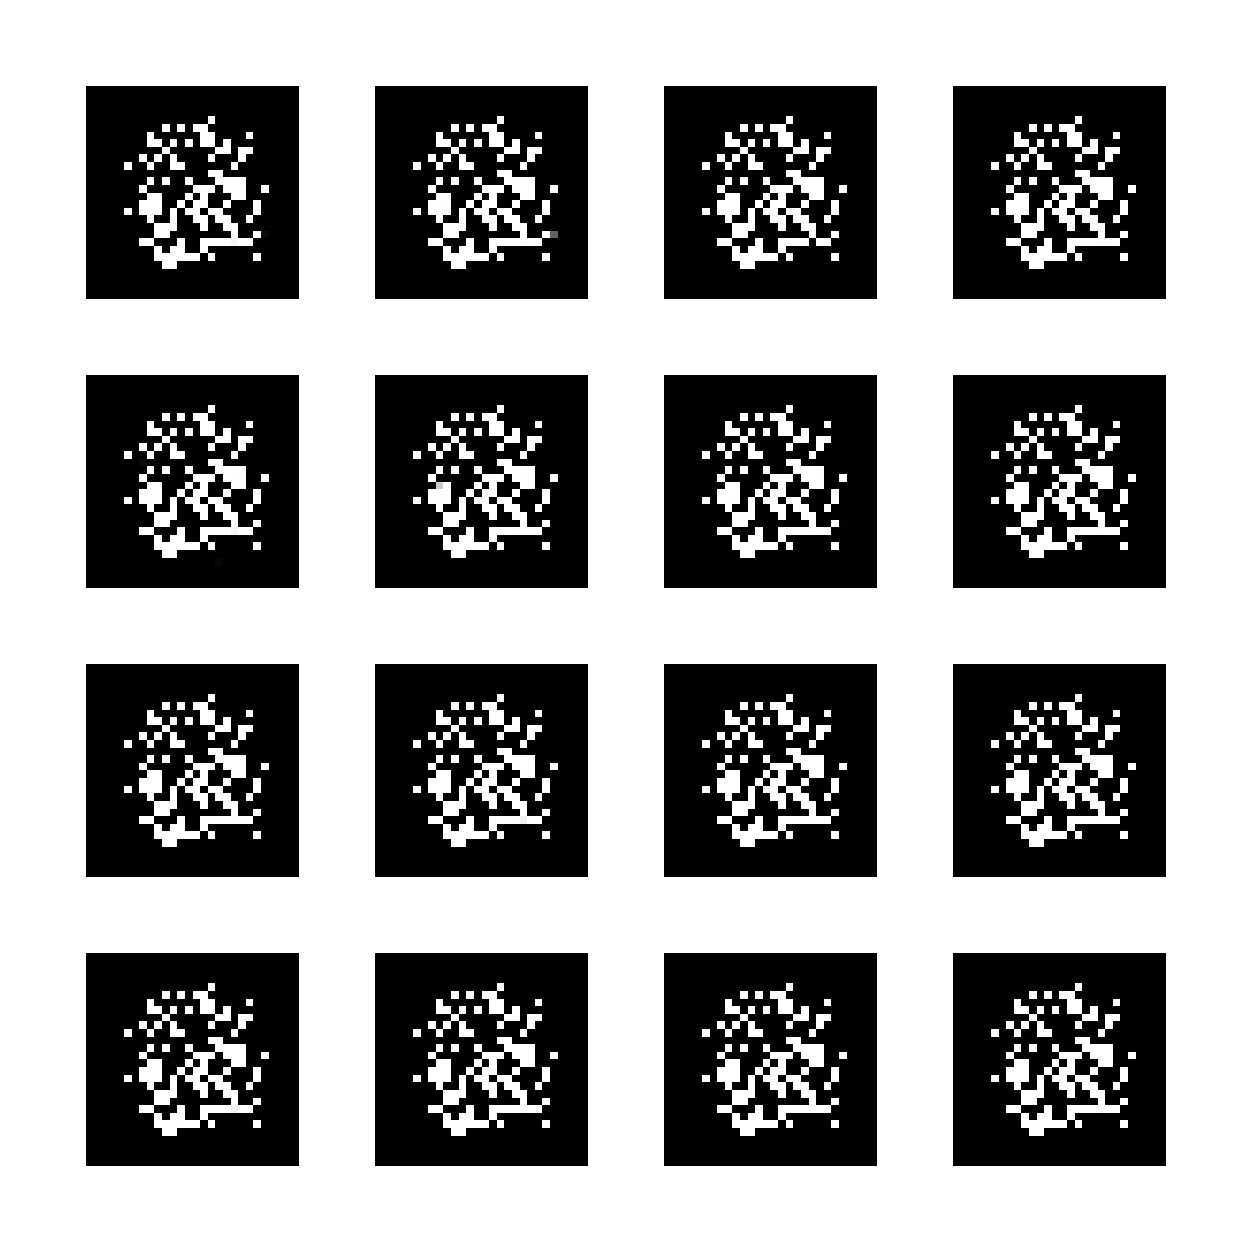

In [16]:
# Visualize Results (Version 2)
generated = generator(test_set).detach().cpu().view(-1, 1, 28, 28)

grid = torchvision.utils.make_grid(
    generated,
    nrow=4,
    padding=10,
    pad_value=1
)

img = np.transpose(
    grid.numpy(),
    (1, 2, 0)
)

fig = plt.figure(figsize=(16, 16))
plt.axis("off")
plt.imshow(img);

## Assignment

### Coding Exercise

- Implement GAN on FashionMNIST Dataset
  - Train on 1 class only
  - Train on 3 classes
  - Add dropout layers
  - Try uniform noise instead of random (Gaussian) noise
  - Instead of Sigmoid at Generator output, try Tanh
  - Implement Cross-Validation to find the best Number of Pieces for Maxout Activation
  - Visualize the gradients at each iteration

### Reading Assignment

- Ian J. Goodfellow, Jean Pouget-Abadie, Mehdi Mirza, Bing Xu, David Warde-Farley, Sherjil Ozair, Aaron Courville, and Yoshua Bengio. 2014. **Generative adversarial nets.**
- Ian J. Goodfellow, David Warde-Farley, Mehdi Mirza, Aaron Courville, and Yoshua Bengio. 2013. **Maxout networks.**
- Ian Goodfellow, Yoshua Bengio, and Aaron Courville. 2016. **Deep Learning**. The MIT Press.
  - Chapter 20: Deep Generative Models, Section 20.14: **Evaluating Generative Models**
  - Chapter 6: Deep Feedforward Networks, Section 6.3.1: **Rectified Linear Units and Their Generalizations**